## Imports

In [1]:
import os
from pathlib import Path
import sys

# Move notebook working directory to the project root
os.chdir("/Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope")

# Make sure Python can import the package
sys.path.insert(0, str(Path.cwd()))

print("Current working directory:", Path.cwd())
print("raw_data exists:", Path("raw_data").exists())
print("preprocessed_data exists:", Path("preprocessed_data").exists())

Current working directory: /Users/lilyeastwood/code/mi-mi-mia/smart-stethoscope
raw_data exists: True
preprocessed_data exists: True


In [2]:

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from keras import layers, models, Input, optimizers
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from keras.applications import MobileNetV2

from smart_stethoscope.ml_logic.data_loading import load_data
from smart_stethoscope.ml_logic.preprocessing import preprocess_tabular_data

## Functions and Preprocessing

In [3]:
# functions
# Assumes these already exist from previous steps:

def wav_to_mel_spec(
    cycle_filename,
    audio_folder,
    n_mels=64,
    max_time_steps=200
):

    """
    Convert one breathing cycle .wav file into a fixed-size mel spectrogram.

    Parameters
    ----------
    cycle_filename : str
        Breathing cycle filename without the .wav extension.
        Example: '101_1b1_Al_sc_Meditron_0'
    audio_folder : str or Path
        Folder containing extracted breathing cycle .wav files.
    n_mels : int, default=64
        Number of mel frequency bins.
    max_time_steps : int, default=200
        Fixed width for the spectrogram.
        If spectrogram is shorter, pad with zeros.
        If longer, crop.

    Returns
    -------
    mel_spec_db : np.ndarray
        2D array of shape (n_mels, max_time_steps)
    """

    # Build full file path
    file_path = Path(audio_folder) / f"{cycle_filename}.wav"

    # Load audio at original sample rate
    signal, sr = librosa.load(file_path, sr=None)

    # Convert waveform to mel spectrogram (power scale)
    mel_spec = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=n_mels
    )

    # Convert to decibel scale for better modelling / visualisation
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Current shape is (n_mels, time_steps)
    current_time_steps = mel_spec_db.shape[1]

    # Pad with zeros on the right if too short
    if current_time_steps < max_time_steps:
        pad_width = max_time_steps - current_time_steps
        mel_spec_db = np.pad(
            mel_spec_db,
            pad_width=((0, 0), (0, pad_width)),
            mode="constant"
        )

    # Crop on the right if too long
    elif current_time_steps > max_time_steps:
        mel_spec_db = mel_spec_db[:, :max_time_steps]

    return mel_spec_db

def build_backbone():
    """
    Load MobileNetV2 pretrained on ImageNet.
    include_top=False drops the ImageNet classifier head —
    we're replacing it with our own for 6 respiratory classes.
    pooling='avg' adds GlobalAveragePooling automatically,
    so the output is a flat vector, not a 3D feature map.
    """
    backbone = MobileNetV2(
        input_shape=(64, 200, 3),
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    backbone.trainable = False  # freeze all backbone weights
    return backbone


def build_model(num_classes):
    """
    Assemble the full transfer learning model.
    We use the functional API (not Sequential) because we need
    the Lambda layer to handle the 1→3 channel conversion before
    passing through the backbone.
    """
    backbone = build_backbone()

    inputs = Input(shape=(64, 200, 1))

    # MobileNetV2 expects 3 channels (like RGB images).
    # Our spectrograms have 1 channel, so we repeat it 3 times.
    # No information is added — it's just satisfying the input contract.
    x = layers.Lambda(lambda x: tf.repeat(x, 3, axis=-1))(inputs)

    # training=False is critical here — it keeps BatchNorm layers
    # in inference mode even while we train the head below.
    # Without this, BatchNorm would update its statistics using
    # our small dataset and corrupt the pretrained features.
    x = backbone(x, training=False)

    # Our new trainable head — these layers learn from scratch
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    # compile model
    model.compile(
        optimizer=optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def build_mel_dataset(
    cycle_filenames,
    audio_folder,
    n_mels=64,
    max_time_steps=200):
    """
    Convert a list/array of cycle filenames into a 4D tensor for CNN input.

    Parameters
    ----------
    cycle_filenames : iterable of str
        Cycle filenames without .wav extension
    audio_folder : str or Path
        Folder containing cycle .wav files
    n_mels : int, default=64
        Number of mel bins
    max_time_steps : int, default=200
        Fixed spectrogram width

    Returns
    -------
    X : np.ndarray
        CNN-ready tensor of shape (n_samples, n_mels, max_time_steps, 1)
    """

    mel_specs = []

    for cycle_filename in cycle_filenames:
        # convert each wav to a mel spec
        mel = wav_to_mel_spec(
            cycle_filename=cycle_filename,
            audio_folder=audio_folder,
            n_mels=n_mels,
            max_time_steps=max_time_steps
        )
        # add each 2D array to the list
        mel_specs.append(mel)

    # Stack into one 3D array: (n_samples, n_mels, max_time_steps)
    X = np.stack(mel_specs)

    # Add channel dimension for expected CNN shape: (n_samples, n_mels, max_time_steps, 1)
    X = X[..., np.newaxis]

    return X

def plot_history(history, title='', axs=None, exp_name=""):
    if axs is not None:
        ax1, ax2 = axs
    else:
        f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if len(exp_name) > 0 and exp_name[0] != '_':
        exp_name = '_' + exp_name
    ax1.plot(history.history['loss'], label='train' + exp_name)
    ax1.plot(history.history['val_loss'], label='val' + exp_name)
    #ax1.set_ylim(0., 2.2)
    ax1.set_title('loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='train accuracy'  + exp_name)
    ax2.plot(history.history['val_accuracy'], label='val accuracy'  + exp_name)
    #ax2.set_ylim(0.25, 1.)
    ax2.set_title('Accuracy')
    ax2.legend()
    return (ax1, ax2)

In [4]:
# Load the full dataframe
df = load_data()

print("Raw df shape:", df.shape)
print(df.columns.tolist())


✅ Processed audio files already exist, skipping extraction

Load data from cached CSV...
Raw df shape: (6898, 13)
['start', 'end', 'crackles', 'wheezes', 'filename', 'chest_location', 'cycle_filename', 'disease', 'age', 'sex', 'adult_bmi', 'child_weight', 'child_height']


In [5]:
# Run preprocessing to get split outputs
X_train_tab, X_val_tab, X_test_tab, y_train, y_val, y_test, train_cycle_filenames, val_cycle_filenames, test_cycle_filenames = preprocess_tabular_data(df)

# Calculate number of classes
num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

# Check class labels
print("Unique train labels:", sorted(y_train.unique()))
print("Unique test labels:", sorted(y_test.unique()))

# Build train and test image tensors
cycle_audio_path = "preprocessed_data/audio_breathing_cycles"

# Check shape of data
print("y_train shape before encoding:", y_train.shape)
print("y_test shape before encoding:", y_test.shape)


X_train_img = build_mel_dataset(
    cycle_filenames=train_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

X_test_img = build_mel_dataset(
    cycle_filenames=test_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

X_val_img = build_mel_dataset(
    cycle_filenames=val_cycle_filenames,
    audio_folder=cycle_audio_path,
    n_mels=64,
    max_time_steps=200
)

# Convert integer labels to one-hot encoded arrays
# Example: class 2 becomes [0, 0, 1, 0, 0, 0]
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)

# Convert one-hot back to integer labels
y_train_int = np.argmax(y_train_cat, axis=1)
y_val_int = np.argmax(y_val_cat, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weights_dict = dict(enumerate(class_weights))

print("Class weights:", class_weights_dict)

print("X_train_tab shape:", X_train_tab.shape)
print("X_test_tab shape:", X_test_tab.shape)
print("X_val_tab.shape()")
print("Number of train cycle filenames:", len(train_cycle_filenames))
print("Number of test cycle filenames:", len(test_cycle_filenames))
print("Number of val cycle filenames:", len(val_cycle_filenames))

Number of classes: 6
Unique train labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Unique test labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
y_train shape before encoding: (4889,)
y_test shape before encoding: (1054,)


/Users/lilyeastwood/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/lilyeastwood/.pyenv/versions/3.10.6/envs/smart-stethoscope/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Class weights: {0: np.float64(3.8435534591194966), 1: np.float64(0.19946960424316607), 2: np.float64(4.879241516966068), 3: np.float64(11.809178743961352), 4: np.float64(3.573830409356725), 5: np.float64(6.365885416666667)}
X_train_tab shape: (4889, 14)
X_test_tab shape: (1054, 14)
X_val_tab.shape()
Number of train cycle filenames: 4889
Number of test cycle filenames: 1054
Number of val cycle filenames: 917


# Transfer learning experimentation

In [6]:
#load best cnn so far for comparison
model = tf.keras.models.load_model('models/best_cnn_model.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 200, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 100, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 100, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,164 (70.96 KB)

 Trainable params: 6,054 (23.65 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,110 (47.31 KB)

# Transfer model 1 

In [7]:
transfer_model = build_model(num_classes=6)
transfer_model.summary()

/var/folders/hb/slylbb8s7834q8vhwkxrntmc0000gn/T/ipykernel_35004/2174342895.py:76: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 200, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 64, 200, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,358 (8.93 MB)

 Trainable params: 82,374 (321.77 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = transfer_model.fit(
    X_train_img,
    y_train_cat,
    validation_data=(X_val_img, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.4070 - loss: 1.6220 - val_accuracy: 0.3784 - val_loss: 1.6962
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.4936 - loss: 1.2988 - val_accuracy: 0.4002 - val_loss: 1.4956
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.5111 - loss: 1.1792 - val_accuracy: 0.4864 - val_loss: 1.4174
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.5613 - loss: 1.1097 - val_accuracy: 0.3381 - val_loss: 1.7079
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.5447 - loss: 1.0609 - val_accuracy: 0.5671 - val_loss: 1.1480
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.5723 - loss: 0.9667 - val_accuracy: 0.4853 - val_loss: 1.4208
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.5701 - loss: 0.9659 - val_accuracy: 0.4973 - val_loss: 1.3047
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.6153 - loss: 0.8543 - val_acc

(<Axes: title={'center': 'loss'}>, <Axes: title={'center': 'Accuracy'}>)

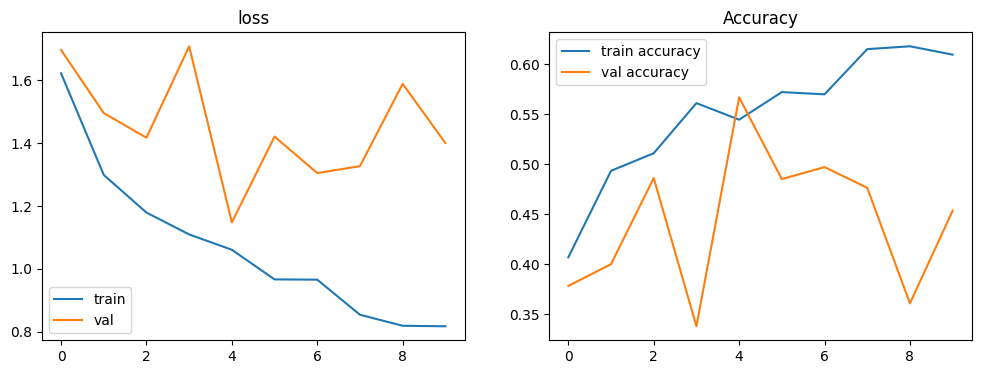

In [9]:
plot_history(history, title='first transfer learning model')

In [10]:
test_loss, test_accuracy = transfer_model.evaluate(X_test_img, y_test_cat, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

y_pred_probs = transfer_model.predict(X_test_img)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred, zero_division=0))

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6176 - loss: 1.0417
Test loss: 1.0416793823242188
Test accuracy: 0.6176470518112183
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step
              precision    recall  f1-score   support

           0       0.13      0.07      0.09        57
           1       0.93      0.71      0.80       891
           2       0.02      0.05      0.03        43
           3       0.06      0.21      0.10        24
           4       0.09      0.31      0.14        26
           5       0.03      0.15      0.04        13

    accuracy                           0.62      1054
   macro avg       0.21      0.25      0.20      1054
weighted avg       0.79      0.62      0.69      1054



# Transfer model 2

/var/folders/hb/slylbb8s7834q8vhwkxrntmc0000gn/T/ipykernel_35004/2174342895.py:76: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.3021 - loss: 1.7946 - val_accuracy: 0.4100 - val_loss: 1.4492
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.4490 - loss: 1.4515 - val_accuracy: 0.3468 - val_loss: 1.5736
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.4794 - loss: 1.3260 - val_accuracy: 0.3926 - val_loss: 1.4939
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.5271 - loss: 1.2553 - val_accuracy: 0.3926 - val_loss: 1.5525
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.5277 - loss: 1.1778 - val_accuracy: 0.4798 - val_loss: 1.3532
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.5633 - loss: 1.1320 - val_accuracy: 0.4471 - val_loss: 1.4185
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.5829 - loss: 1.0696 - val_accuracy: 0.4329 - val_loss: 1.4728
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.5874 - loss: 1.0334 - val_

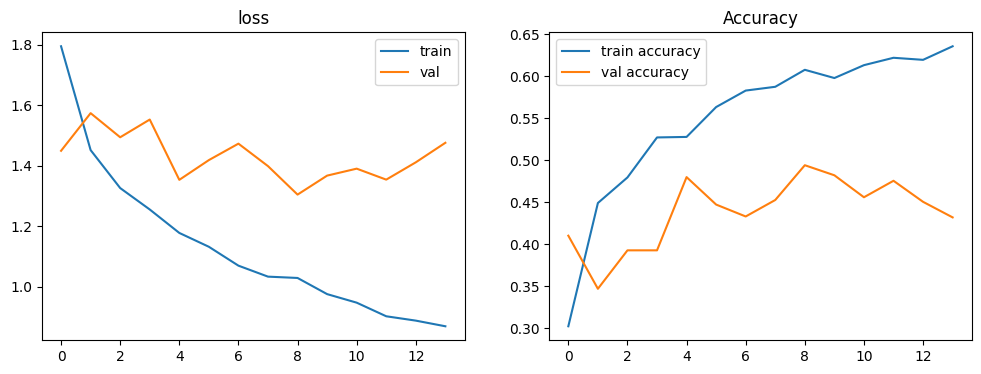

In [11]:
# Transfer model 2 — lower learning rate
transfer_model2 = build_model(num_classes=6)

transfer_model2.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history2 = transfer_model2.fit(
    X_train_img,
    y_train_cat,
    validation_data=(X_val_img, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping],
    verbose=1
)

plot_history(history2, title='transfer model 2 - lower lr')

test_loss, test_accuracy = transfer_model2.evaluate(X_test_img, y_test_cat, verbose=1)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

y_pred_probs = transfer_model2.predict(X_test_img)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_int = np.argmax(y_test_cat, axis=1)

print(classification_report(y_test_int, y_pred, zero_division=0))